<a href="https://colab.research.google.com/github/eyramg/A01-data-wrangling/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing?

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

In [3]:
import pandas as pd

police = pd.read_csv("./data/mn_police_use_of_force.csv")

police["subject_injury"].value_counts(dropna=False)

,count
subject_injury,
NaN,9848
Yes,1631
No,1446


In [2]:
!git clone https://github.com/eyramg/A01-data-wrangling.git
%cd A01-data-wrangling

Cloning into 'A01-data-wrangling'...
remote: Enumerating objects: 12, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 12 (delta 0), reused 0 (delta 0), pack-reused 9 (from 1)
Receiving objects: 100% (12/12), 3.43 MiB | 7.83 MiB/s, done.
/content/A01-data-wrangling


In [4]:
# proportion of subject_injury values that are missing
missing_prop = police["subject_injury"].isna().mean()
missing_prop

np.float64(0.7619342359767892)

**Declaration:** I completed this version without generative AI.

**Student(s):**Eyram Golo

**Date:** 09/06/2026

In [27]:
airbnb = pd.read_csv("./data/airbnb_hw.csv")

airbnb["Price"].head(20)

,Price
0,145
1,37
2,28
3,199
4,549
5,149
6,250
7,90
8,270
9,290


In [28]:
airbnb["Price_clean"] = (
    airbnb["Price"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("$", "", regex=False)
)

airbnb["Price_clean"] = pd.to_numeric(
    airbnb["Price_clean"],
    errors="coerce"
)

airbnb["Price_clean"].head()

,Price_clean
0,145
1,37
2,28
3,199
4,549


In [29]:
airbnb["Price_clean"].isna().sum()

np.int64(0)

In [ ]:
# Your Phase 1 solution to the problem goes here.
Q1.
1. I first looked at teh price where  i noticed teh prices had formattting characters. I took away teh dollar signs and commas so that teh values could be converted from text to numbers. Then i converted from text to numbers .After cleaning I found 9,848 missing values.
2. SO after noticing taht about 76% was missing, i realized we were lossing a lot of data,  The missingness differes by force_type rather than being uniformly related.
The original variable already had consistent Yes and No values, but it contained many missing values. I kept Yes and No as they were and represented the missing observations as Unknown rather than treating them as No, because a missing injury status does not tell us that an injury did not occur.

In [6]:
police["subject_injury_clean"] = police["subject_injury"].fillna("Unknown")

police["subject_injury_clean"].value_counts()

,count
subject_injury_clean,
Unknown,9848
Yes,1631
No,1446


In [5]:
pd.crosstab(
    police["force_type"],
    police["subject_injury"],
    dropna=False
)

subject_injury,No,Yes,NaN
force_type,,,
Baton,0,2,2
Bodily Force,1093,1286,7051
Chemical Irritant,131,41,1421
Firearm,2,0,0
Gun Point Display,33,44,27
Improvised Weapon,34,40,74
Less Lethal,0,0,87
Less Lethal Projectile,1,2,0
Maximal Restraint Technique,0,0,170


In [7]:
sharks = pd.read_excel("/content/GSAF5.xls")

sharks.head()

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,26th August,2026.0,Unprovoked,USA,Hawaii,"Ala Moana Beach Park, Oah'u",Surfing,Unknown Female,F,?,...,Tiger Shark,Keith Cowley: KHON: KITV:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,23rd August,2026.0,Unprovoked,USA,Florida,Boca Grande (island in the keys),Wading on a sandbar,David Daniel,M,43,...,Large shark,Keith Cowley: Todd Smith: NBC 6: ABC News:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,19th August,2026.0,Provoked,Reunion Island,Saint-Gilles-les-Baines,Outer Reef Roches Noires,Spearfishiong,Male,M,?,...,Bull shark 2.5m (8.2 ft),Todd Smith: Local Report Zinfos 874:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11th August,2026.0,Provoked,Ireland,Waterford,Ardemore County,Fishing,Sebastian Achim,M,27,...,1.5m (5ft) Blue shark,Keith Cowley: David Bargh: Irish Times BBC Met...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8th August,2026.0,Unprovoked,USA,Maine,Scarborough Beach Park,Operation of Rescue Torpedo,Greg Wilfert,M,71,...,Great White Shark,WGME: CBS News: Keith Cowley,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
sharks.isna().all()

,0
Date,False
Year,False
Type,False
Country,False
State,False
Location,False
Activity,False
Name,False
Sex,False
Age,False


In [9]:
sharks = sharks.dropna(axis=1, how="all")
sharks.shape

(7117, 23)

In [10]:
sharks["Year"].value_counts(dropna=False).sort_index()

,count
Year,
0.0,129
5.0,1
77.0,1
1000.0,1
1500.0,1
...,...
2023.0,109
2024.0,52
2025.0,69


In [11]:
sharks_1940 = sharks[sharks["Year"] >= 1940].copy()

sharks_1940["Year"].agg(["min", "max"])

,Year
min,1940.0
max,2026.0


In [12]:
attacks_per_year = sharks_1940["Year"].value_counts().sort_index()
attacks_per_year

,count
Year,
1940.0,24
1941.0,27
1942.0,41
1943.0,28
1944.0,31
...,...
2022.0,98
2023.0,109
2024.0,52


<Axes: title={'center': 'Recorded Shark Attacks Since 1940'}, xlabel='Year', ylabel='Number of Shark Attacks'>

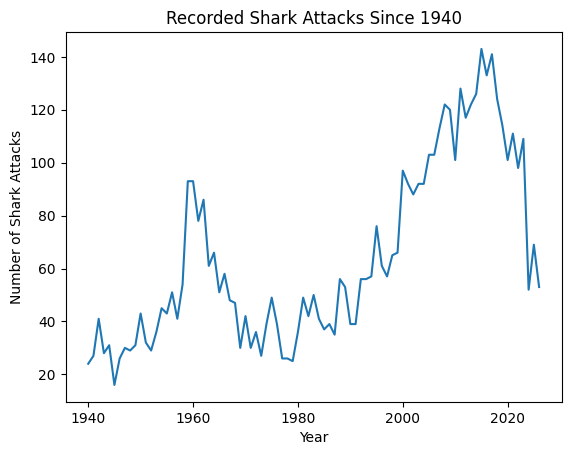

In [13]:
attacks_per_year.plot(
    xlabel="Year",
    ylabel="Number of Shark Attacks",
    title="Recorded Shark Attacks Since 1940"
)

In [ ]:
Q2 #3

In [15]:

sharks_1940["Age"].value_counts(dropna=False)


,count
Age,
NaN,1777
16,80
19,80
17,79
15,76
...,...
"""young""",1
7 or 8,1
78,1


In [16]:
sharks_1940["Age_clean"] = pd.to_numeric(
    sharks_1940["Age"],
    errors="coerce"
)

sharks_1940["Age_clean"].describe()

,Age_clean
count,3645.000000
mean,28.638409
std,14.843747
min,1.000000
25%,17.000000
50%,25.000000
75%,38.000000
max,87.000000


Text(0.5, 1.0, 'Age of Shark Attack Victims')

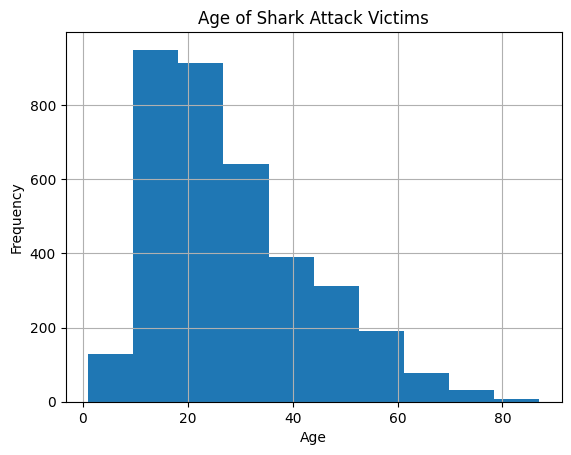

In [18]:
import matplotlib.pyplot as plt
sharks_1940["Age_clean"].hist()

plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age of Shark Attack Victims")

In [ ]:
Q2 #4

In [19]:
sharks_1940["Sex"].value_counts(dropna=False)

,count
Sex,
M,4384
F,730
NaN,451
M,7
?,2
F,2
M F,1
M,1
m,1


In [20]:
sharks_1940["Sex_clean"] = (
    sharks_1940["Sex"]
    .astype("string")
    .str.strip()
    .str.upper()
)

sharks_1940["Sex_clean"].value_counts(dropna=False)

,count
Sex_clean,
M,4393
F,732
<NA>,451
?,2
M F,1
LLI,1
M X 2,1


In [21]:
known_sex = sharks_1940["Sex_clean"].isin(["M", "F"])

male_proportion = (
    sharks_1940.loc[known_sex, "Sex_clean"] == "M"
).mean()

male_proportion

np.float64(0.8571707317073171)

In [ ]:
Q2 #5

In [22]:
sharks_1940["Type"].value_counts(dropna=False)

,count
Type,
Unprovoked,4161
Provoked,526
Invalid,402
Watercraft,280
Sea Disaster,156
Questionable,27
NaN,14
Boat,7
Provoked,2


In [24]:
type_temp = sharks_1940["Type"].astype("string").str.strip().str.lower()

In [25]:
sharks_1940["Type_clean"] = "Unknown"

sharks_1940.loc[type_temp == "provoked", "Type_clean"] = "Provoked"
sharks_1940.loc[type_temp == "unprovoked", "Type_clean"] = "Unprovoked"

sharks_1940["Type_clean"].value_counts()

,count
Type_clean,
Unprovoked,4163
Unknown,890
Provoked,528


In [26]:
unprovoked_proportion = (
    sharks_1940["Type_clean"] == "Unprovoked"
).mean()

unprovoked_proportion

np.float64(0.7459236695932628)

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]